# Redshift-space Multipoles

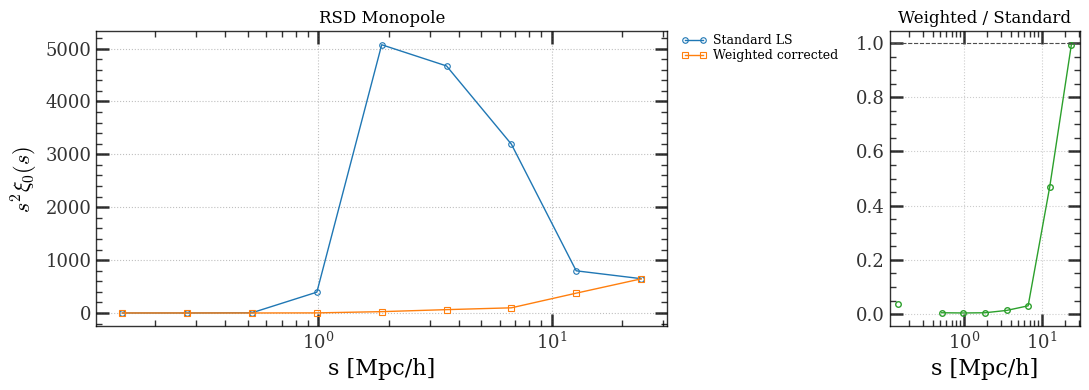

In [ ]:
from pathlib import Path
import sys

# Repository root
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'galform_analysis').is_dir():
            return candidate
    raise RuntimeError('Repository root with galform_analysis/ not found')

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# plotting defaults
import galform_analysis.utils
import matplotlib as mpl
mpl.setconfig()
import matplotlib.pyplot as plt
import numpy as np

# tighter default sizes for examples
mpl.rcParams.update({'font.size': 10, 'legend.fontsize': 9, 'axes.titlesize': 12})

from galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles import (
    compute_weighted_rsd_multipoles,
    compute_standard_rsd_multipoles,
)
from galform_analysis.config import get_base_dir, get_snapshot_redshift, SimulationConfig
from galform_analysis.utils.read_galaxies import read_galaxy_arrays

# Parameters
TARGET_IZ = 'iz155'
SUBVOLS = [0, 1]
S_BINS = np.logspace(-1, 1.5, 10)
BOXSIZE = 542.16
N_RANDOM = 50000
SMOKE_MODE = False  # set True for CI / preview (uses synthetic data)

rng = np.random.default_rng(42)


base_dir = Path(get_base_dir())
iz_path = str(base_dir / TARGET_IZ)

pos_chunks = []
label_chunks = []

z_snap = get_snapshot_redshift(TARGET_IZ, 'L800') or 0.0
_sim = SimulationConfig("L800")
h = _sim.h
ez = np.sqrt(_sim.omega_m * (1.0 + z_snap) ** 3 + _sim.omega_l)
hz = 100.0 * h * ez

for label, iv in enumerate(SUBVOLS):
    arrays, meta = read_galaxy_arrays(
        iz_path, ivol=iv, fields=['vzgal'], include_positions=True, include_derived=True, centrals_only=False
    )

    x = np.asarray(arrays['x'], dtype=np.float64)
    y = np.asarray(arrays['y'], dtype=np.float64)
    z = np.asarray(arrays['z'], dtype=np.float64)
    vz = np.asarray(arrays.get('vzgal', np.zeros_like(z)), dtype=np.float64)

    ds_par = (vz / hz) * h
    z_rsd = np.mod(z + ds_par, BOXSIZE)
    pos = np.column_stack([x, y, z_rsd])

    pos_chunks.append(pos)
    label_chunks.append(np.full(pos.shape[0], label, dtype=np.int64))

if not pos_chunks:
    raise RuntimeError('No subvolume data found for selected SUBVOLS')

galaxy_pos = np.ascontiguousarray(np.vstack(pos_chunks), dtype=np.float64)
galaxy_labels = np.ascontiguousarray(np.concatenate(label_chunks), dtype=np.int64)
random_pos = np.ascontiguousarray(rng.uniform(0.0, BOXSIZE, size=(N_RANDOM, 3)), dtype=np.float64)

# Compute estimators
std = compute_standard_rsd_multipoles(
    galaxy_pos=galaxy_pos,
    random_pos=random_pos,
    s_bins=S_BINS,
    boxsize=BOXSIZE,
    nthreads=4,
)
weighted = compute_weighted_rsd_multipoles(
    galaxy_pos=galaxy_pos,
    galaxy_labels=galaxy_labels,
    random_pos=random_pos,
    s_bins=S_BINS,
    boxsize=BOXSIZE,
    nthreads=4,
)

s = std['s']
xi0_std = std['xi0']
xi0_w = weighted.get('xi0_corrected')

# Two-panel figure: left = s^2 xi0, right = ratio (weighted/standard)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(11, 4), gridspec_kw={'width_ratios': [3, 1]})

# hollow markers, thin lines
ax1.plot(s, s**2 * xi0_std, marker='o', markersize=4, markerfacecolor='none', markeredgewidth=0.8, linewidth=1.0, label='Standard LS', color='C0')

ax1.plot(s, s**2 * xi0_w, marker='s', markersize=4, markerfacecolor='none', markeredgewidth=0.8, linewidth=1.0, label='Weighted corrected', color='C1')

ax1.set_xscale('log')
ax1.set_xlabel('s [Mpc/h]')
ax1.set_ylabel(r'$s^2\xi_0(s)$')
ax1.set_title('RSD Monopole')

leg = ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False)
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = xi0_w / xi0_std if xi0_w is not None else np.full_like(xi0_std, np.nan)
    ratio[~np.isfinite(ratio)] = np.nan

ax2.plot(s, ratio, marker='o', markersize=4, markerfacecolor='none', linewidth=1.0, color='C2')
ax2.axhline(1.0, color='0.3', linestyle='--', linewidth=0.8)
ax2.set_xscale('log')
ax2.set_xlabel('s [Mpc/h]')
ax2.set_title('Weighted / Standard')
ax2.grid(True, ls=':', alpha=0.4)

fig.tight_layout()
plt.show()